In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
weather_df = pd.read_csv("../tsf_compare/data/weather/jena_climate_2009_2016.csv")
weather_df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
weather_df.shape

(420551, 15)

In [4]:
import pandas as pd

def _prepare_dataframe(df):
    if "Date Time" not in df.columns:
        raise ValueError("DataFrame must contain a 'Date Time' column.")

    df = df.copy()

    df["Date Time"] = pd.to_datetime(
        df["Date Time"],
        format="%d.%m.%Y %H:%M:%S",
        errors="raise"
    )

    df = df.sort_values("Date Time")
    df.set_index("Date Time", inplace=True)

    return df


def _get_resolution(df):
    """
    Estimate the sampling interval using the median difference.
    Returns a pandas Timedelta.
    """
    diffs = df.index.to_series().diff().dropna()

    if diffs.empty:
        raise ValueError("DataFrame must contain at least two timestamps.")

    return diffs.median()


def group_by_hour(df):
    """
    Group data by hour only if the original frequency is finer than 1 hour.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(hours=1):
        raise ValueError(
            f"Cannot group by hour. Data resolution is {resolution}."
        )

    return df.resample("1h").mean(numeric_only=True)


def group_by_day(df):
    """
    Group data by day only if the original frequency is finer than 1 day.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(days=1):
        raise ValueError(
            f"Cannot group by day. Data resolution is {resolution}."
        )

    return df.resample("1D").mean(numeric_only=True)


def group_by_month(df):
    """
    Group data by month only if the original frequency is finer than 1 month.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    # Approximate month as 28 days (safe lower bound)
    if resolution >= pd.Timedelta(days=28):
        raise ValueError(
            f"Cannot group by month. Data resolution is {resolution}."
        )

    return df.resample("MS").mean(numeric_only=True)

In [5]:
monthly = group_by_month(weather_df)
monthly.head()
# hourly = group_by_hour(weather_df)
# hourly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,988.988075,-3.626617,270.409572,-5.887934,84.992651,5.000858,4.196778,0.804076,2.652147,4.256180,1276.954094,1.784855,2.892657,150.870558
2009-02-01,985.634010,0.169950,274.473770,-2.186749,84.723492,6.352691,5.353219,0.999516,3.388271,5.435491,1253.876491,2.045833,3.498914,193.228611
2009-03-01,986.123026,3.989944,278.266989,0.353797,78.468752,8.288454,6.389973,1.898461,4.044017,6.485105,1236.608163,2.429601,4.088239,201.683315
2009-04-01,987.523086,11.889757,286.080206,5.742546,69.176981,14.639894,9.316218,5.323556,5.892667,9.439019,1202.978444,1.853863,3.121630,143.162153
2009-05-01,992.105999,13.433905,287.247596,7.815836,70.967000,16.044648,10.835849,5.208658,6.826414,10.927278,1201.285078,2.080842,3.556891,168.264149


In [6]:
monthly.to_csv("../tsf_compare/data/weather/jena_climate_2009_2016_monthly.csv", index=True)

In [6]:
monthly.shape
# hourly.shape

(97, 14)

In [7]:
97//12

8

### Only using data of 25 days

In [8]:
df = monthly[:8*12]
# df = hourly[:25*24]
df_raw = df.copy()
df.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,988.988075,-3.626617,270.409572,-5.887934,84.992651,5.000858,4.196778,0.804076,2.652147,4.256180,1276.954094,1.784855,2.892657,150.870558
2009-02-01,985.634010,0.169950,274.473770,-2.186749,84.723492,6.352691,5.353219,0.999516,3.388271,5.435491,1253.876491,2.045833,3.498914,193.228611
2009-03-01,986.123026,3.989944,278.266989,0.353797,78.468752,8.288454,6.389973,1.898461,4.044017,6.485105,1236.608163,2.429601,4.088239,201.683315
2009-04-01,987.523086,11.889757,286.080206,5.742546,69.176981,14.639894,9.316218,5.323556,5.892667,9.439019,1202.978444,1.853863,3.121630,143.162153
2009-05-01,992.105999,13.433905,287.247596,7.815836,70.967000,16.044648,10.835849,5.208658,6.826414,10.927278,1201.285078,2.080842,3.556891,168.264149


In [9]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

/tmp/ipykernel_18251/869362234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df.columns] = scaler.fit_transform(df)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,-0.053382,-1.876246,-1.881137,-1.908056,1.185929,-1.427858,-1.516614,-1.189717,-1.512621,-1.514966,1.933261,0.018025,-0.038018,-1.342376
2009-02-01,-0.900141,-1.329604,-1.294766,-1.254677,1.150255,-1.201663,-1.186626,-1.117470,-1.180869,-1.181758,1.198272,0.081539,0.095189,1.044470
2009-03-01,-0.776685,-0.779589,-0.747491,-0.806188,0.321249,-0.877760,-0.890790,-0.785164,-0.885342,-0.885195,0.648301,0.174937,0.224676,1.520886
2009-04-01,-0.423229,0.357852,0.379778,0.145100,-0.910287,0.184996,-0.055793,0.480966,-0.052204,-0.050583,-0.422758,0.034820,0.012292,-1.776739
2009-05-01,0.733761,0.580183,0.548206,0.511102,-0.673037,0.420046,0.377830,0.438493,0.368612,0.369917,-0.476689,0.090060,0.107928,-0.362260


### Smoothing using rolling mean

In [8]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [10]:
TOTAL_POINTS = len(df)
PERIOD = 8
TRAIN_DAYS = 5
TEST_DAYS = 3
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 8 x 12 x 14


In [11]:
PERIOD*TIME

96

In [12]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(8, 12, 14)

In [13]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (5, 12, 14)
Test tensor shape: (3, 12, 14)


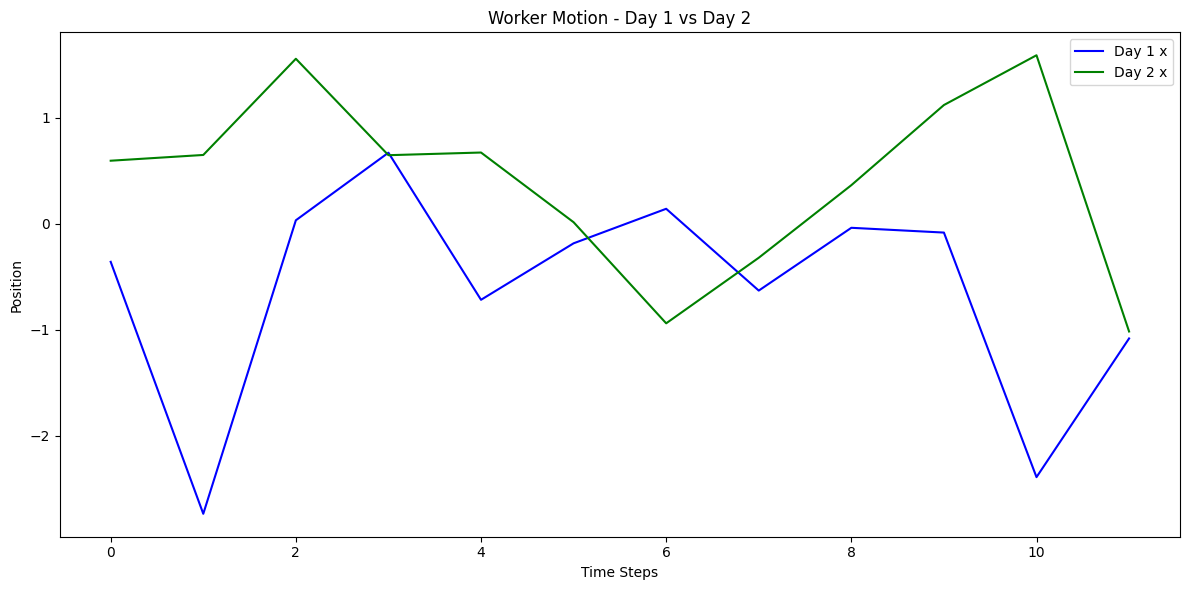

In [14]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [15]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (5, 2)
Time factors shape: (12, 2)
Feature factors shape: (14, 2)


In [16]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (5, 12, 14)
Reconstructed tensor shape: (5, 12, 14)


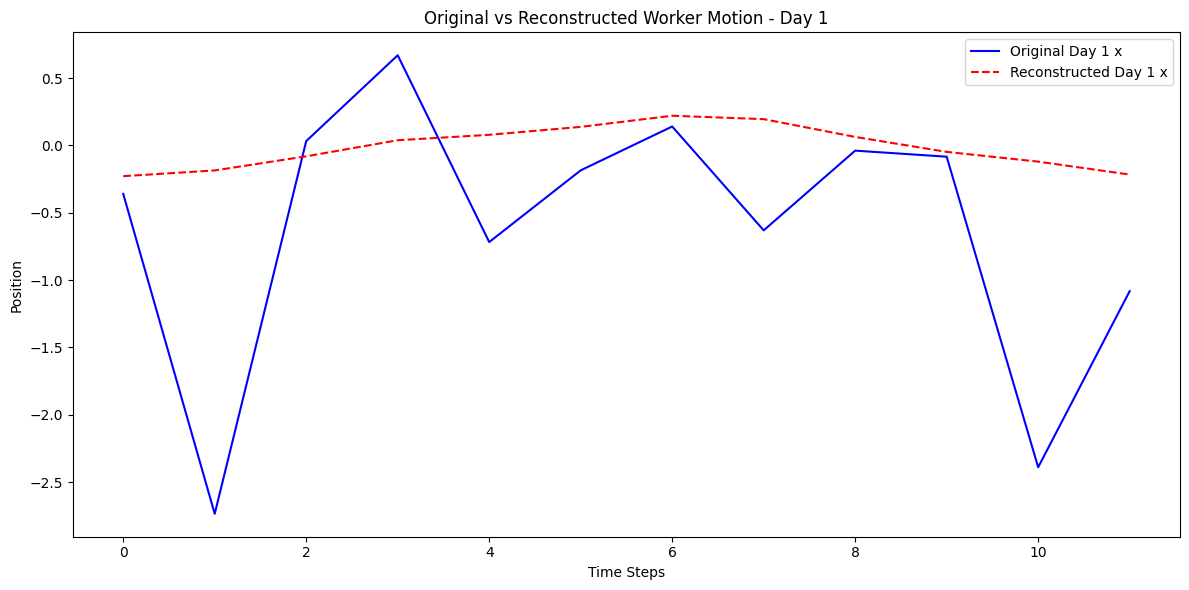

In [17]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [18]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

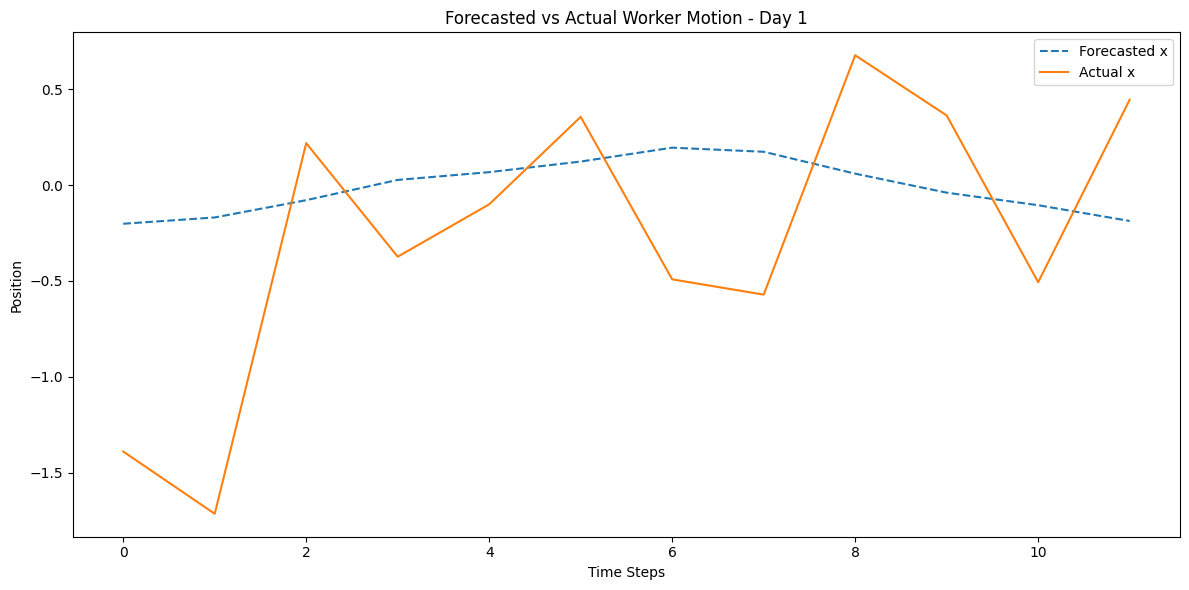

In [19]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

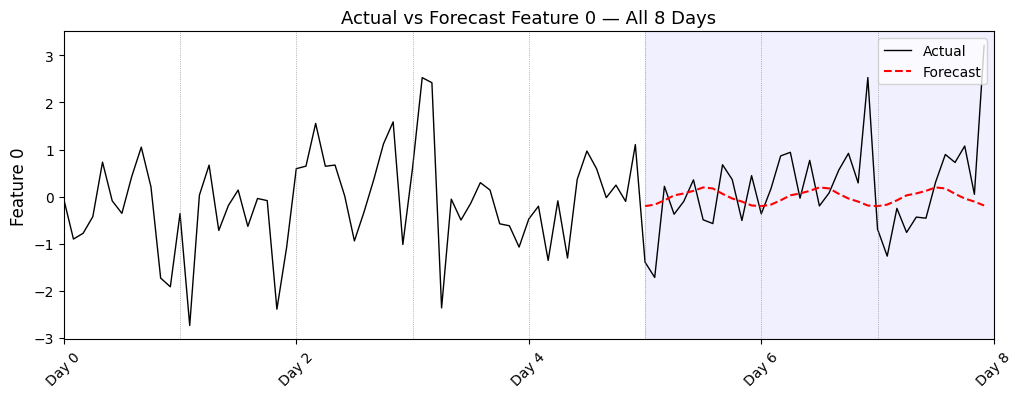

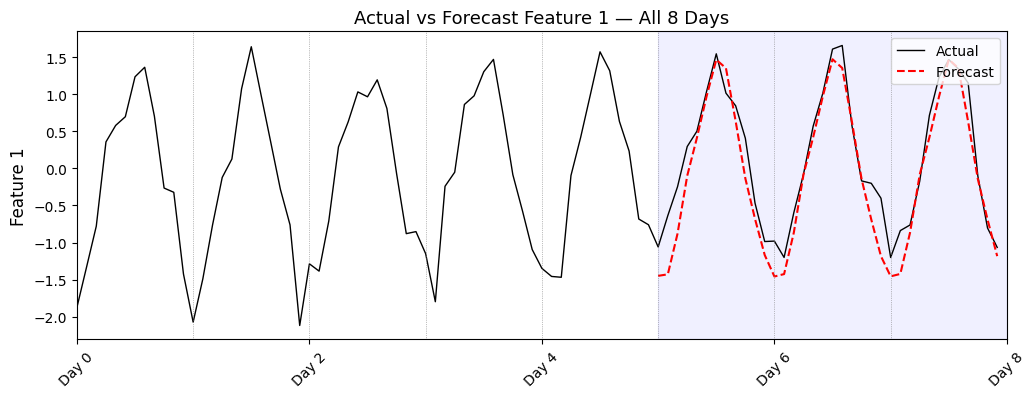

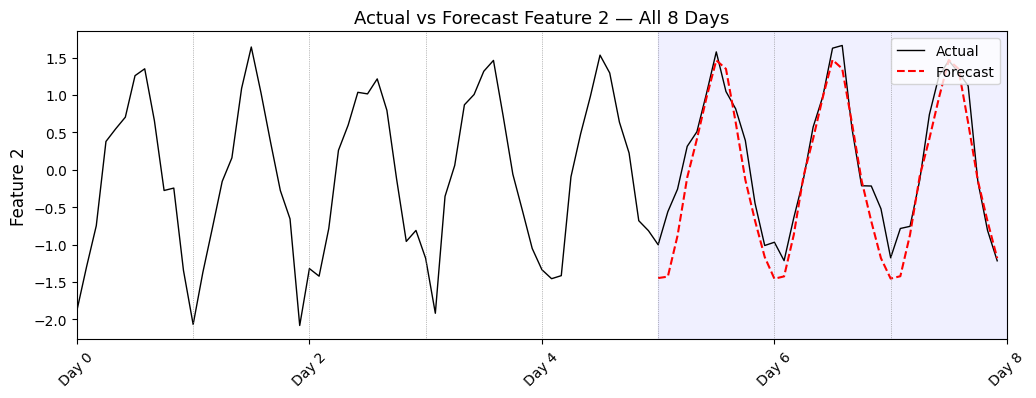

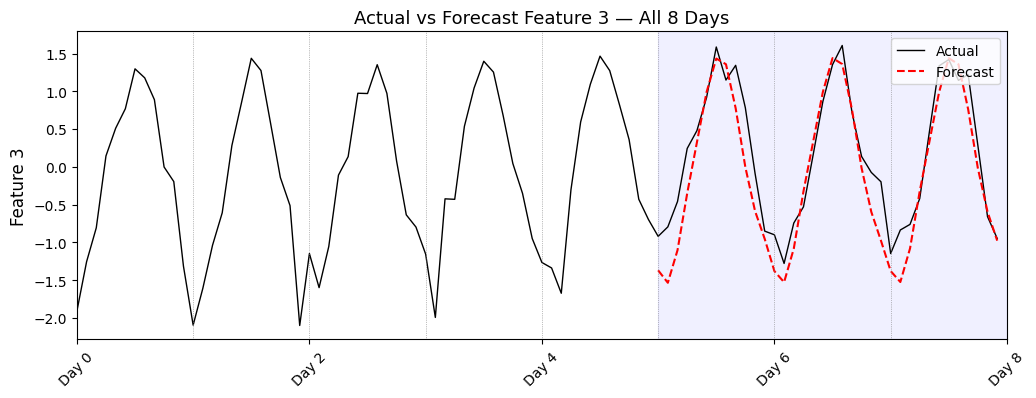

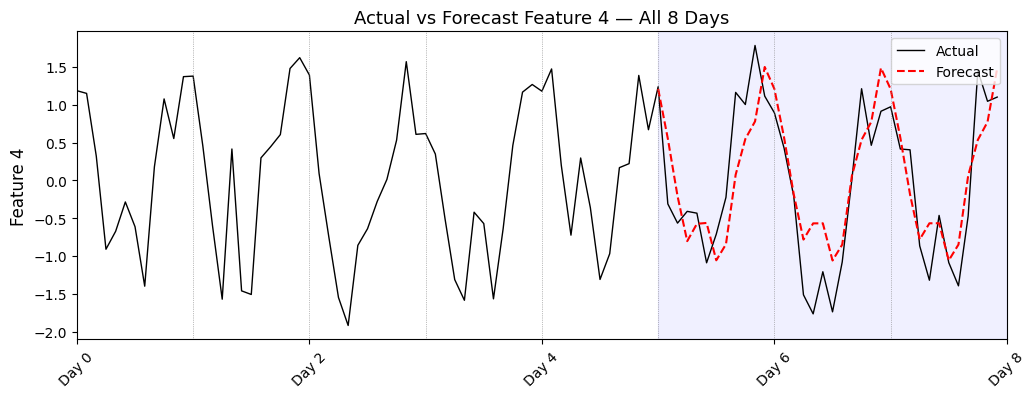

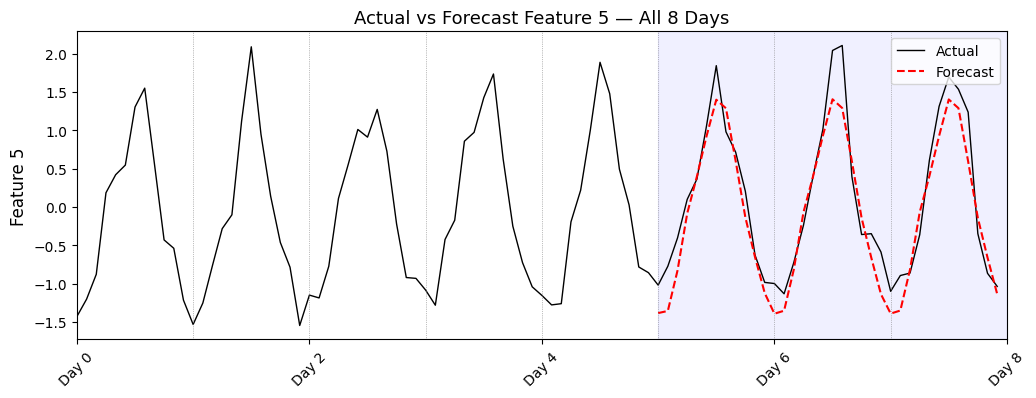

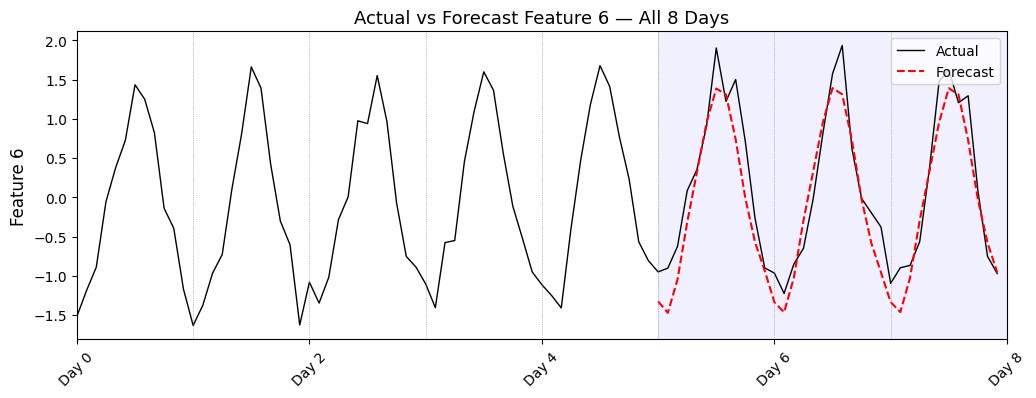

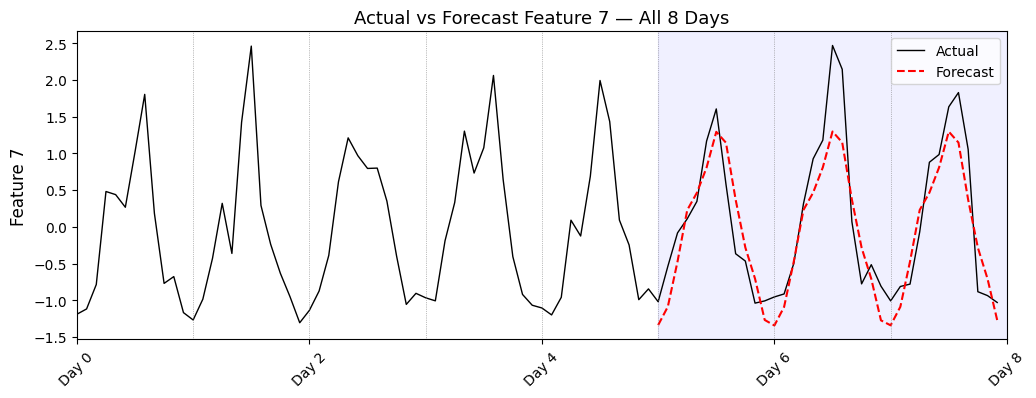

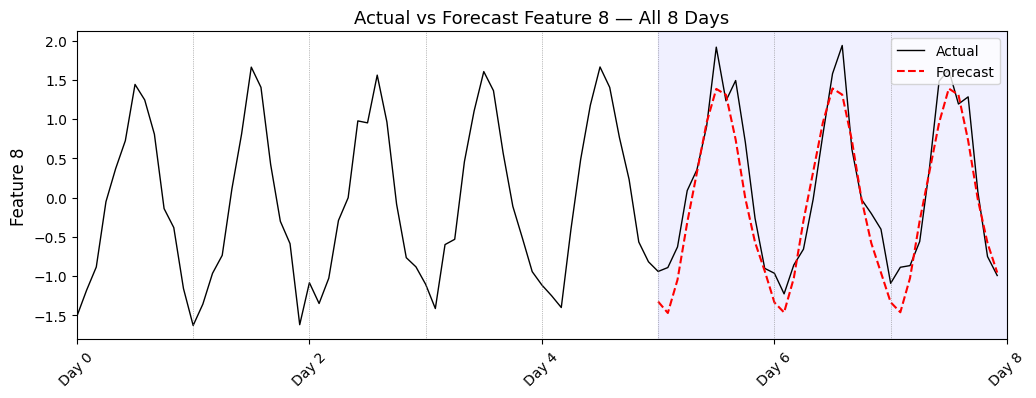

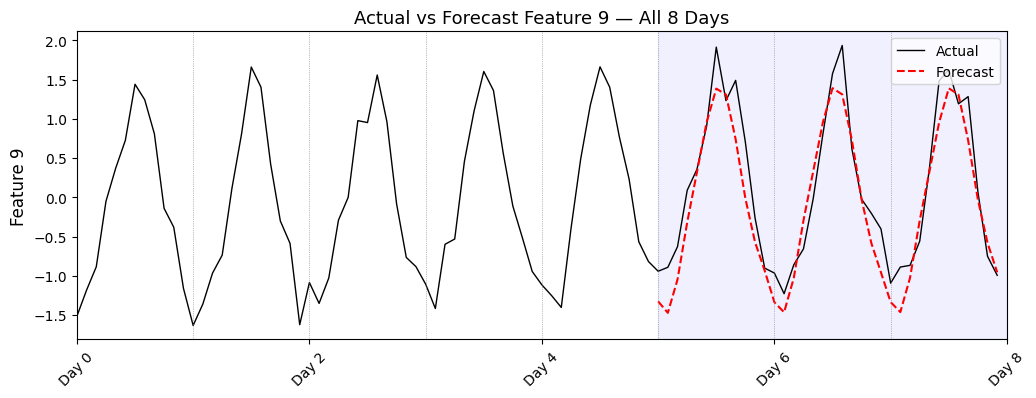

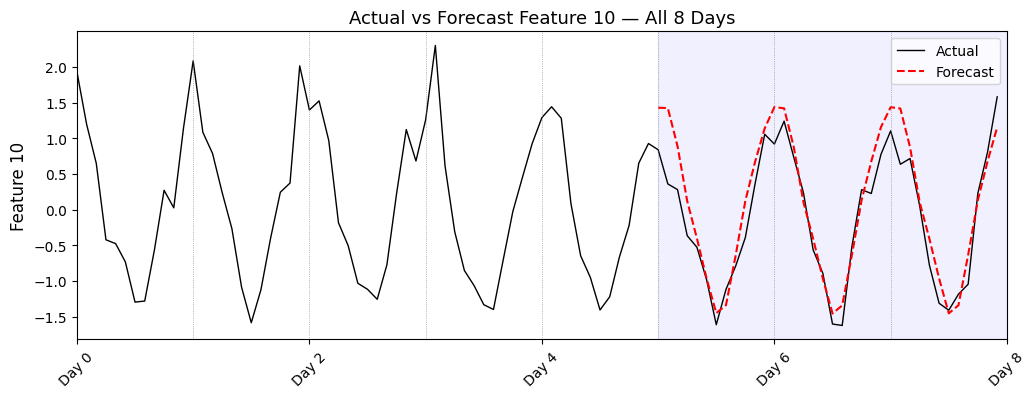

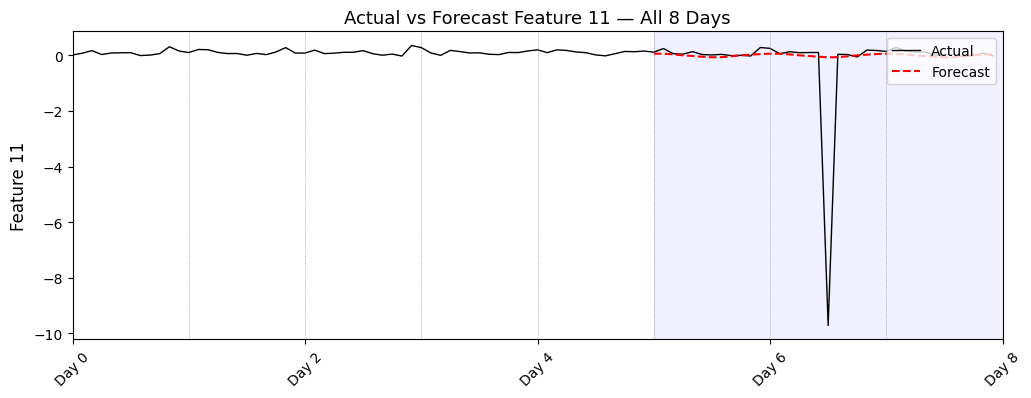

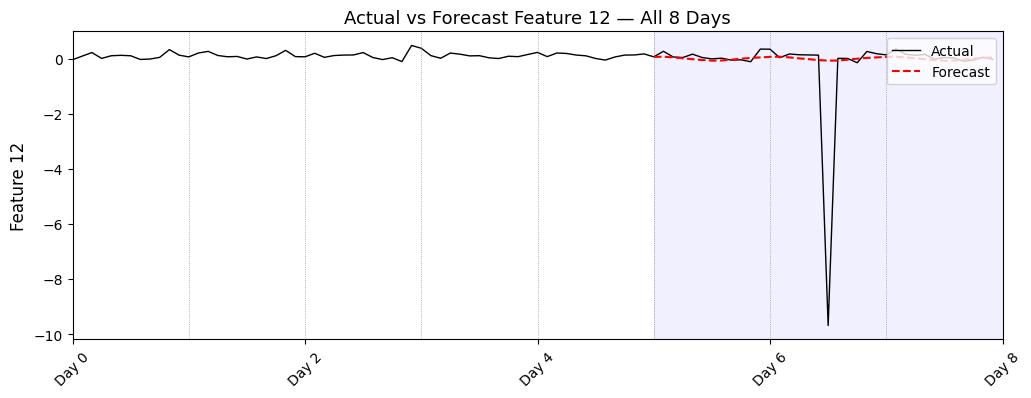

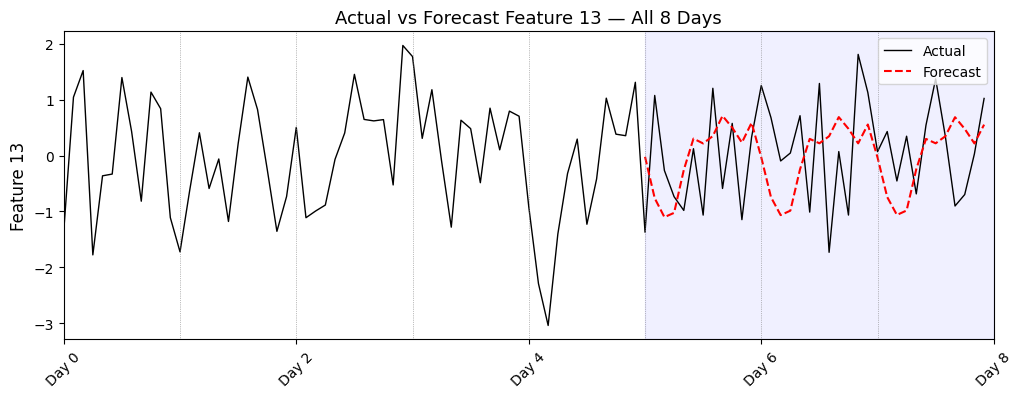

In [20]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

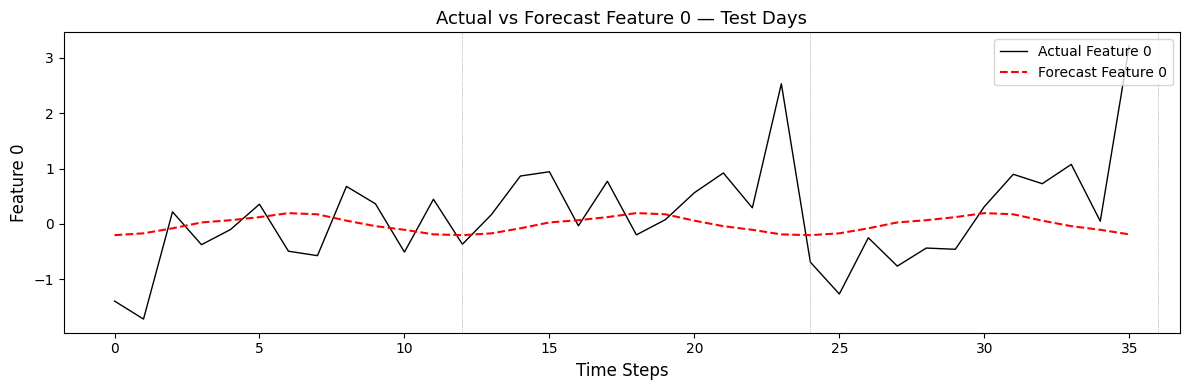

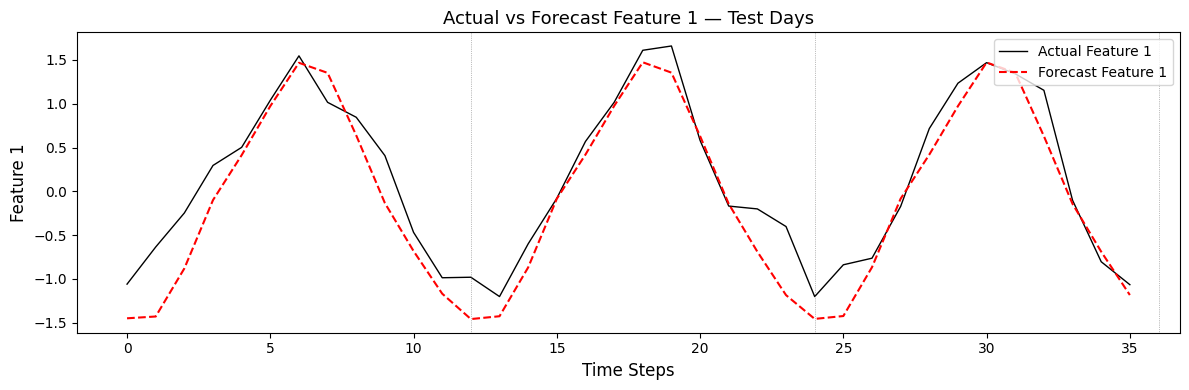

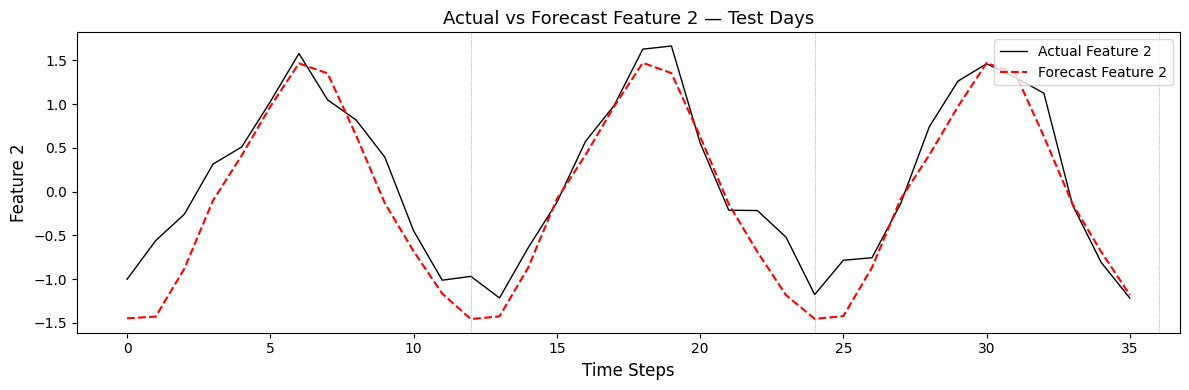

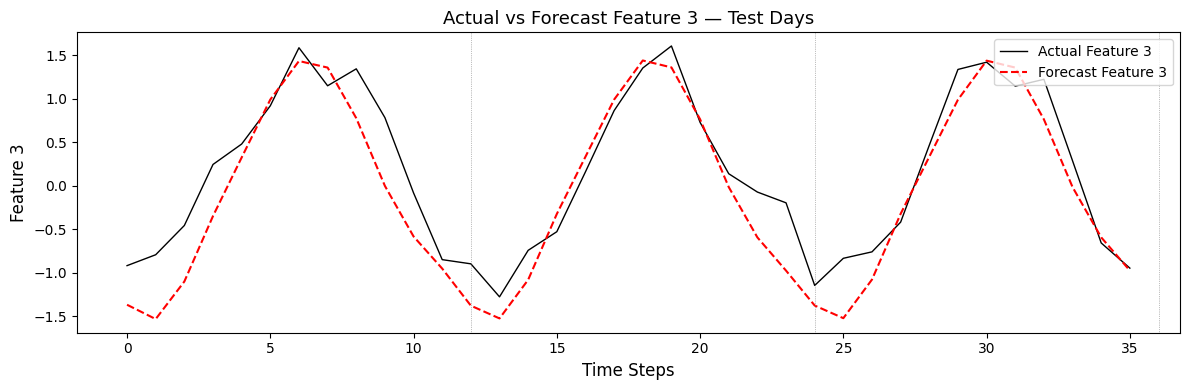

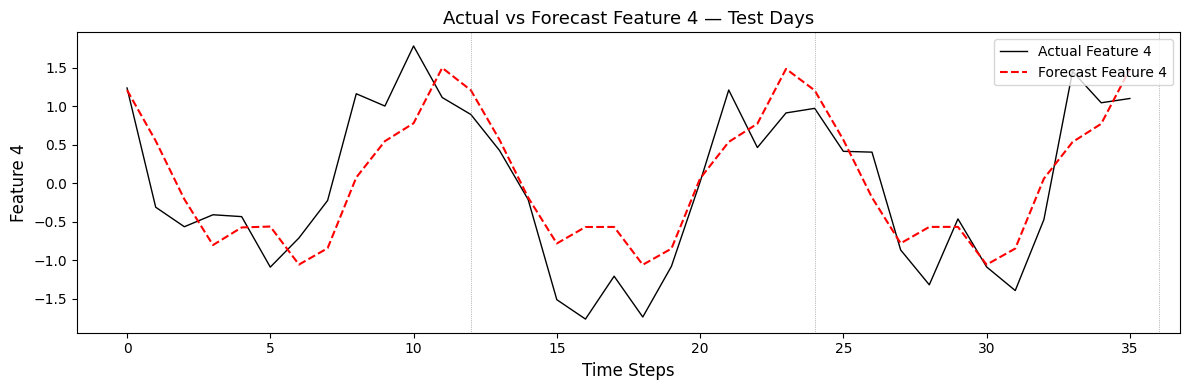

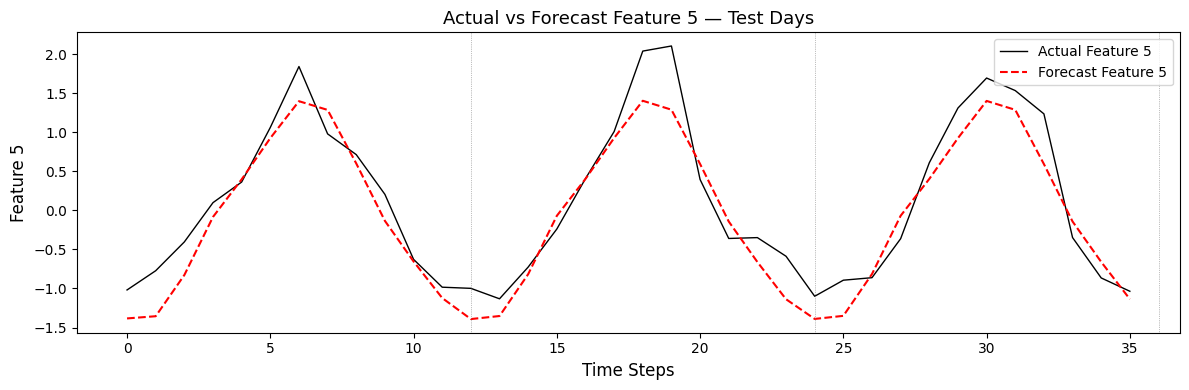

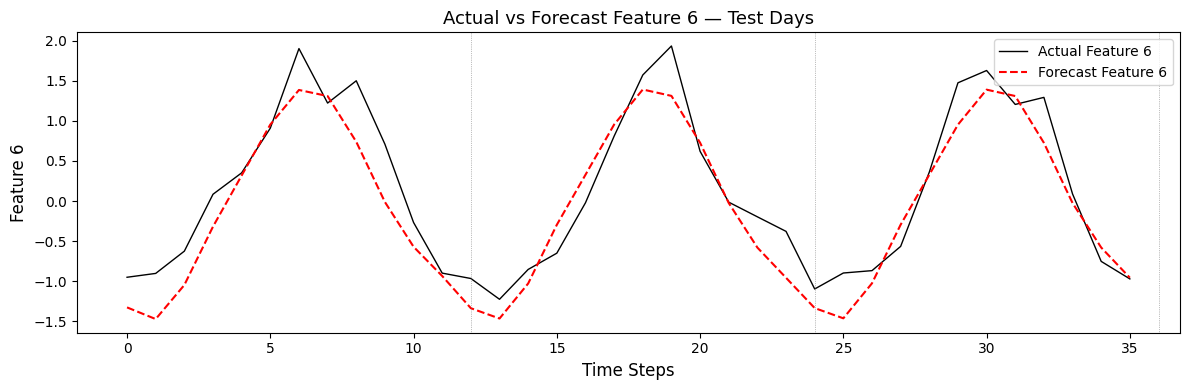

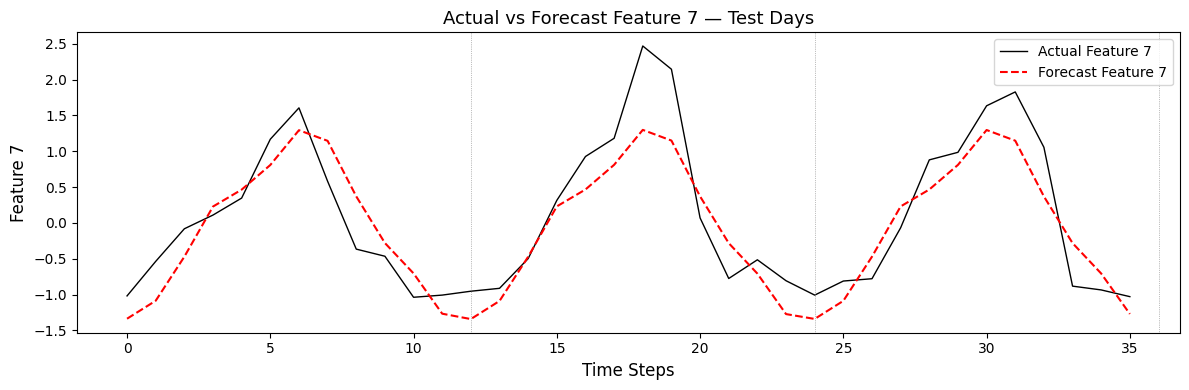

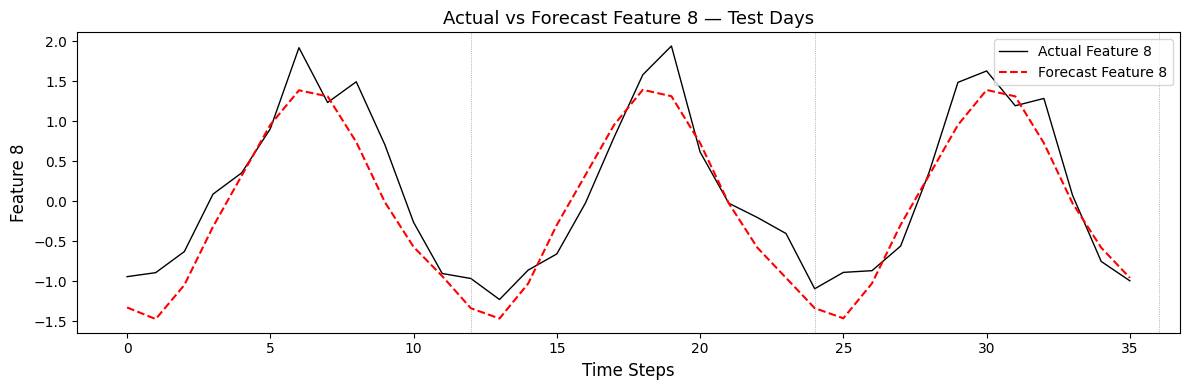

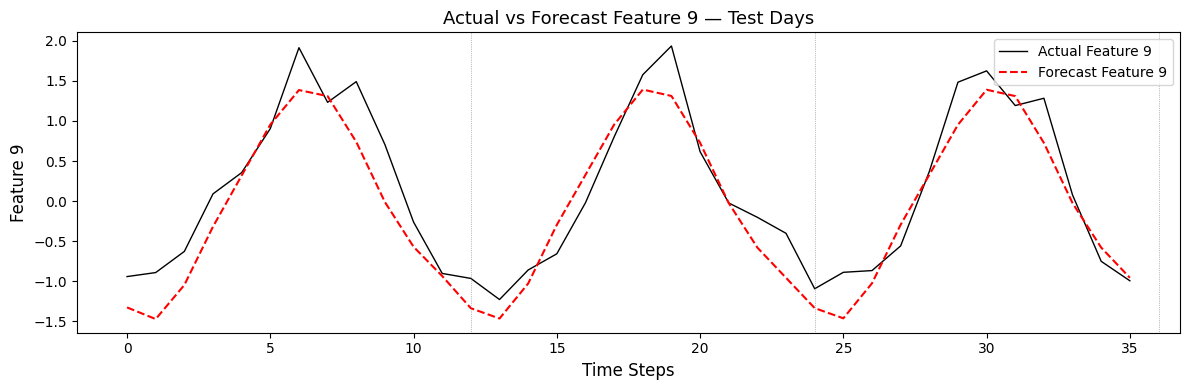

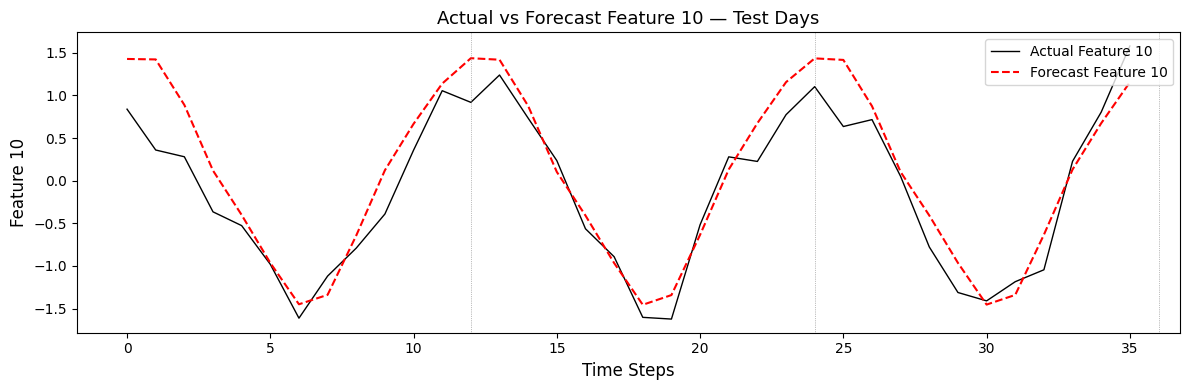

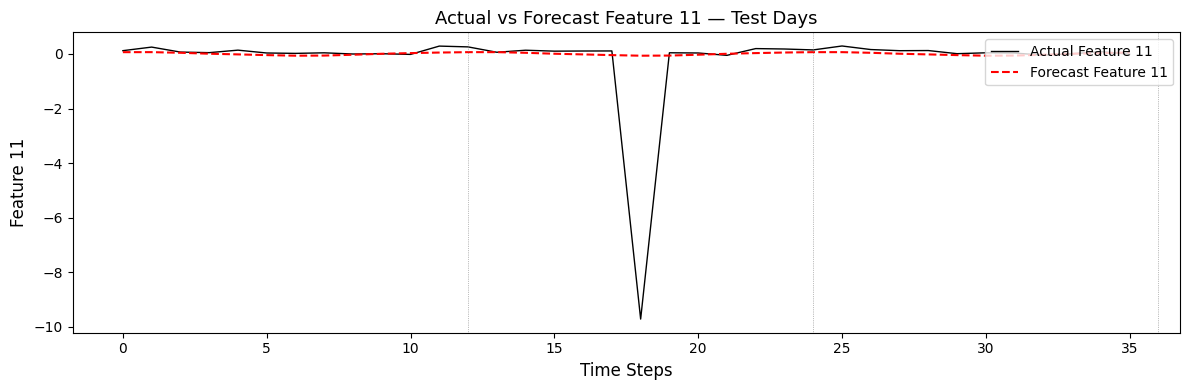

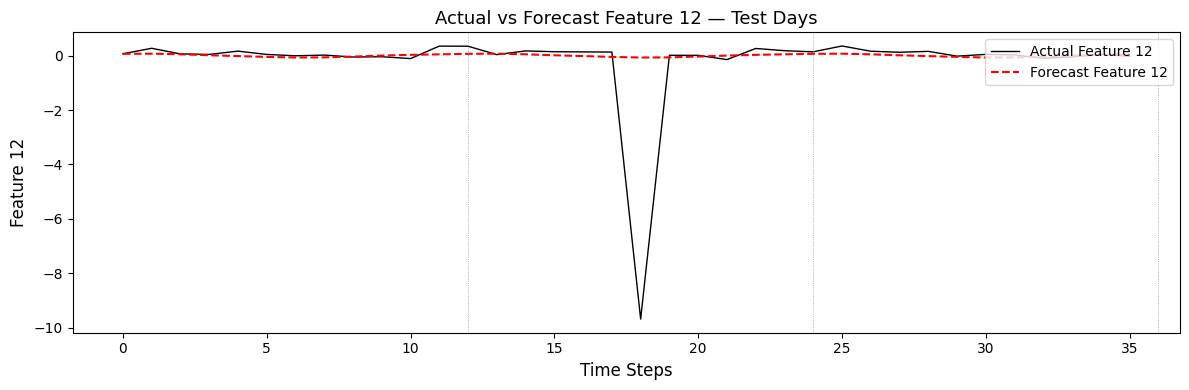

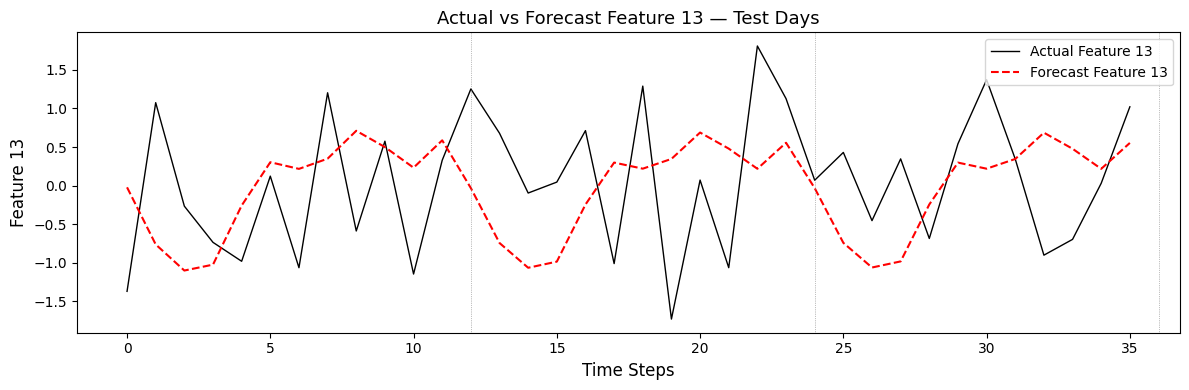

In [21]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [22]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((60, 14), (36, 14))

In [24]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: -0.0617, MSE: 0.9419, MAE: 0.7025, RMSE: 0.9705
Feature 1 R²: 0.8616, MSE: 0.1142, MAE: 0.2579, RMSE: 0.3380
Feature 2 R²: 0.8628, MSE: 0.1144, MAE: 0.2582, RMSE: 0.3382
Feature 3 R²: 0.8132, MSE: 0.1503, MAE: 0.3130, RMSE: 0.3877
Feature 4 R²: 0.7059, MSE: 0.3034, MAE: 0.4545, RMSE: 0.5508
Feature 5 R²: 0.8839, MSE: 0.1160, MAE: 0.2821, RMSE: 0.3406
Feature 6 R²: 0.8607, MSE: 0.1351, MAE: 0.2997, RMSE: 0.3676
Feature 7 R²: 0.8057, MSE: 0.2073, MAE: 0.3874, RMSE: 0.4553
Feature 8 R²: 0.8609, MSE: 0.1353, MAE: 0.3006, RMSE: 0.3678
Feature 9 R²: 0.8609, MSE: 0.1351, MAE: 0.3005, RMSE: 0.3676
Feature 10 R²: 0.8398, MSE: 0.1339, MAE: 0.2876, RMSE: 0.3659
Feature 11 R²: 0.0019, MSE: 2.5971, MAE: 0.3590, RMSE: 1.6115
Feature 12 R²: 0.0026, MSE: 2.5861, MAE: 0.3752, RMSE: 1.6081
Feature 13 R²: -0.4325, MSE: 1.1452, MAE: 0.9245, RMSE: 1.0702
average R²: 0.5618, average MSE: 0.6297, average MAE: 0.3931, average RMSE: 0.6528
